<a href="https://colab.research.google.com/github/marianafreitasc/CicloGuia-HackathonAnalytica/blob/main/acidentes_transito_isp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('acidentes_transito_isp.csv', sep=';')
df

,Ano,Logradouro,Delito,Total
0,2021,Avenida Amaro Cavalcanti,Acidente de trânsito,19
1,2021,Avenida Amaro Cavalcanti,Lesão corporal culposa - trânsito,20
2,2021,Avenida Areia Branca,Acidente de trânsito,14
3,2021,Avenida Areia Branca,Lesão corporal culposa - trânsito,14
4,2021,Avenida Armando Lombardi,Acidente de trânsito,15
...,...,...,...,...
1076,2019,Via Transolimpica,Lesão corporal culposa - trânsito,33
1077,2019,Viaduto Dos Marinheiros,Acidente de trânsito,11
1078,2019,Viaduto Dos Marinheiros,Lesão corporal culposa - trânsito,10
1079,2019,Vila Sem Tipo Sem Nome,Acidente de trânsito,11


###Analise inicial

In [ ]:
#dimensões do dataset
df.shape

(1081, 4)

In [ ]:
#tipos de dados e informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Ano         1081 non-null   int64 
 1   Logradouro  1081 non-null   object
 2   Delito      1081 non-null   object
 3   Total       1081 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 33.9+ KB


In [ ]:
#estatísticas descritivas
df.describe()

,Ano,Total
count,1081.000000,1081.000000
mean,2019.859389,29.321924
std,0.837007,52.821467
min,2019.000000,10.000000
25%,2019.000000,13.000000
50%,2020.000000,19.000000
75%,2021.000000,30.000000
max,2021.000000,856.000000


In [ ]:
#verificação de nulos
df.isnull().sum()

,0
Ano,0
Logradouro,0
Delito,0
Total,0


###Analise Univariada

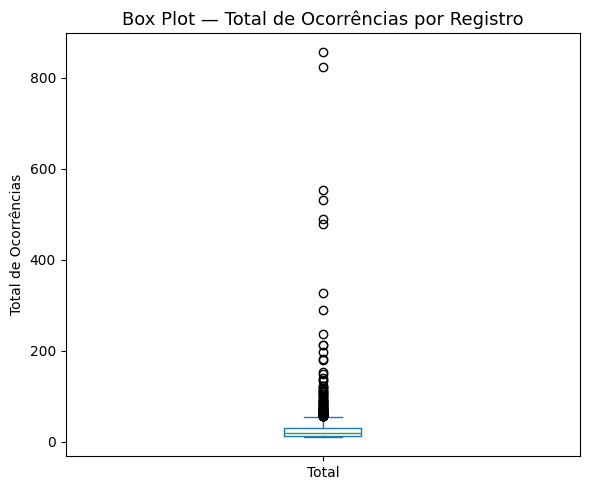

In [ ]:
# Box plot da variável Total
df[['Total']].plot(kind='box', figsize=(6, 5))
plt.title('Box Plot — Total de Ocorrências por Registro', fontsize=13)
plt.ylabel('Total de Ocorrências')
plt.tight_layout()
plt.show()

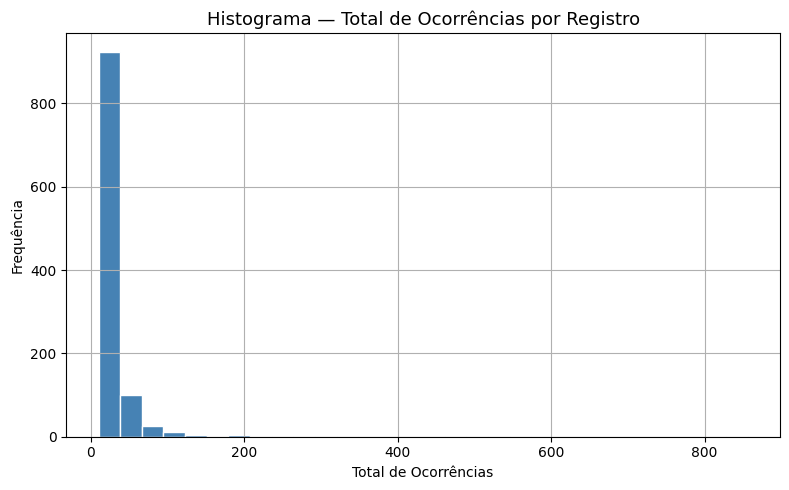

In [ ]:
# Histograma da variável Total
df['Total'].hist(figsize=(8, 5), bins=30, color='steelblue', edgecolor='white')
plt.title('Histograma — Total de Ocorrências por Registro', fontsize=13)
plt.xlabel('Total de Ocorrências')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

In [ ]:
# Contagem de registros por tipo de delito
print('Registros por tipo de Delito:')
print(df['Delito'].value_counts())

Registros por tipo de Delito:
Delito
Lesão corporal culposa - trânsito                      526
Acidente de trânsito                                   491
Atropelamento                                           40
Homicídio culposo - trânsito                            20
Conduzir veículo embriagado ou sob efeito de drogas      2
Falta de habilitação                                     2
Name: count, dtype: int64


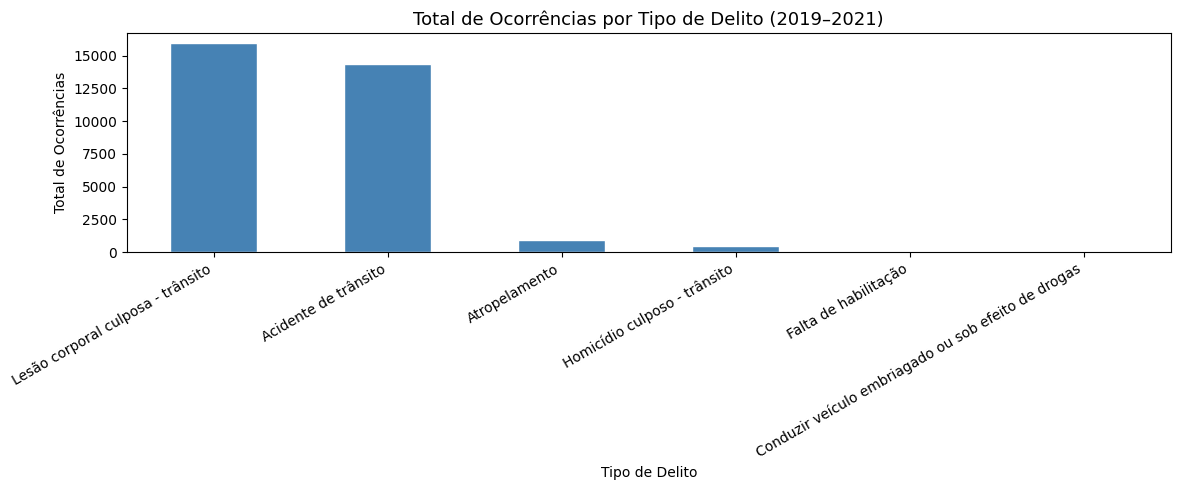

In [ ]:
# Gráfico de barras — total de ocorrências por tipo de delito
total_por_delito = df.groupby('Delito')['Total'].sum().sort_values(ascending=False)
total_por_delito.plot(kind='bar', figsize=(12, 5), color='steelblue', edgecolor='white')
plt.title('Total de Ocorrências por Tipo de Delito (2019–2021)', fontsize=13)
plt.xlabel('Tipo de Delito')
plt.ylabel('Total de Ocorrências')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Total de ocorrências por ano
print('Total de ocorrências por Ano:')
print(df.groupby('Ano')['Total'].sum())

Total de ocorrências por Ano:
Ano
2019    14796
2020     8137
2021     8764
Name: Total, dtype: int64


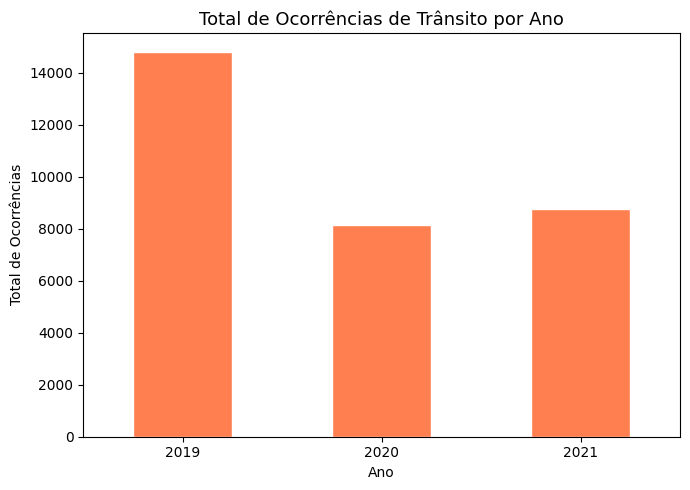

In [ ]:
# Gráfico de barras — total por ano
df.groupby('Ano')['Total'].sum().plot(kind='bar', figsize=(7, 5), color='coral', edgecolor='white')
plt.title('Total de Ocorrências de Trânsito por Ano', fontsize=13)
plt.xlabel('Ano')
plt.ylabel('Total de Ocorrências')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 logradouros com mais ocorrências
print('Top 10 Logradouros mais perigosos:')
print(df.groupby('Logradouro')['Total'].sum().sort_values(ascending=False).head(10))

Top 10 Logradouros mais perigosos:
Logradouro
Avenida Brasil                           4255
Avenida Das Americas                     1560
Avenida Dom Helder Camara                 944
Avenida De Santa Cruz                     726
Avenida Cesario De Melo                   717
Avenida Pastor Martin Luther King Jr.     692
Estrada Dos Bandeirantes                  544
Avenida Ayrton Senna                      507
Avenida Presidente Vargas                 478
Avenida Lucio Costa                       353
Name: Total, dtype: int64


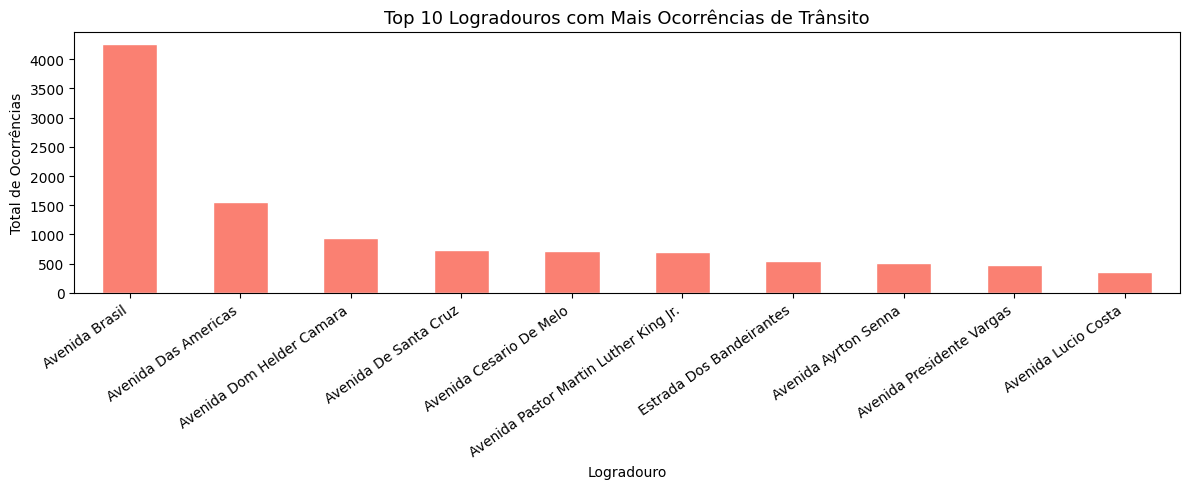

In [ ]:
# Gráfico — top 10 logradouros
top10 = df.groupby('Logradouro')['Total'].sum().sort_values(ascending=False).head(10)
top10.plot(kind='bar', figsize=(12, 5), color='salmon', edgecolor='white')
plt.title('Top 10 Logradouros com Mais Ocorrências de Trânsito', fontsize=13)
plt.xlabel('Logradouro')
plt.ylabel('Total de Ocorrências')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

###Analise multivariada

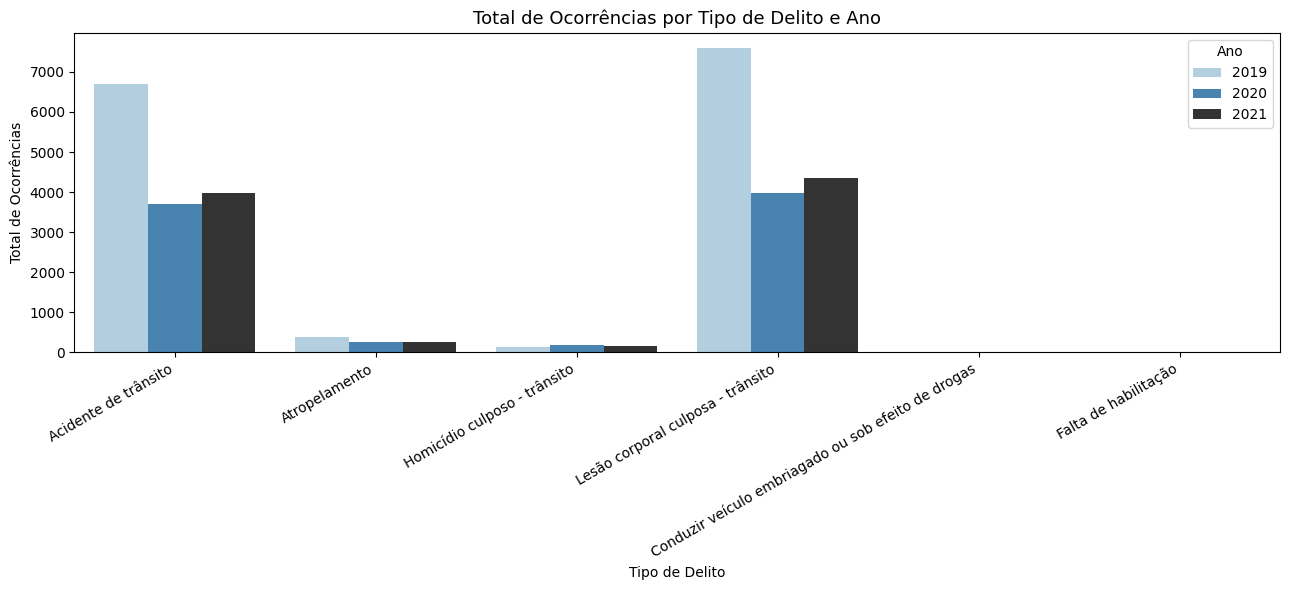

In [ ]:
# Total por ano e delito
total_ano_delito = df.groupby(['Ano', 'Delito'])['Total'].sum().reset_index()

plt.figure(figsize=(13, 6))
sns.barplot(x='Delito', y='Total', hue='Ano', data=total_ano_delito, palette='Blues_d')
plt.title('Total de Ocorrências por Tipo de Delito e Ano', fontsize=13)
plt.xlabel('Tipo de Delito')
plt.ylabel('Total de Ocorrências')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Ano')
plt.tight_layout()
plt.show()

/tmp/ipykernel_11852/3560194687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Delito', y='Total', data=df, palette='pastel')


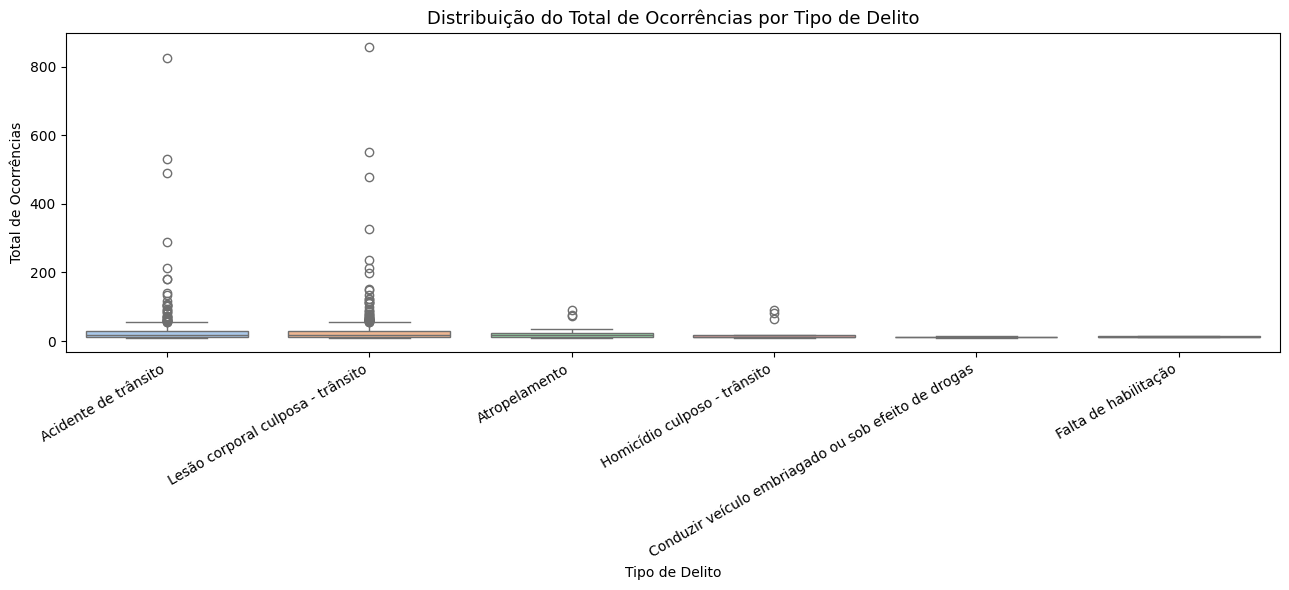

In [ ]:
# Box plot — distribuição do total por tipo de delito
plt.figure(figsize=(13, 6))
sns.boxplot(x='Delito', y='Total', data=df, palette='pastel')
plt.title('Distribuição do Total de Ocorrências por Tipo de Delito', fontsize=13)
plt.xlabel('Tipo de Delito')
plt.ylabel('Total de Ocorrências')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

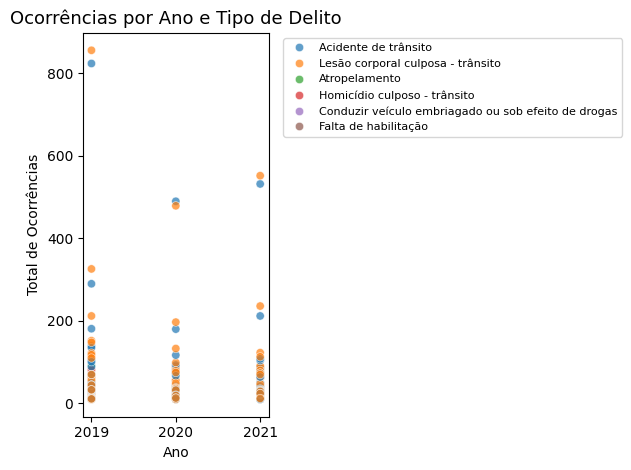

In [ ]:
# Scatter plot — total de ocorrências por ano, colorido por delito
sns.scatterplot(x='Ano', y='Total', hue='Delito', data=df, palette='tab10', alpha=0.7)
plt.title('Ocorrências por Ano e Tipo de Delito', fontsize=13)
plt.xlabel('Ano')
plt.ylabel('Total de Ocorrências')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

###Correlação e Heatmap

In [ ]:
# Matriz de correlação
df_corr = df[['Ano', 'Total']]
df_corr.corr()

,Ano,Total
Ano,1.000000,-0.032986
Total,-0.032986,1.000000


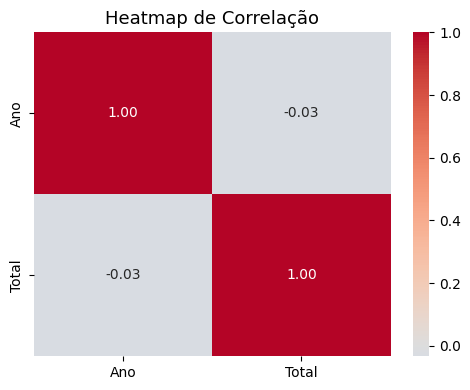

In [ ]:
# Heatmap de correlação
plt.figure(figsize=(5, 4))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap de Correlação', fontsize=13)
plt.tight_layout()
plt.show()

###Conclusões

1.   O dataset possui 1.081 registros e 4 colunas, sem nenhum valor nulo.
2.   Há 6 tipos de delito registrados e 269 logradouros distintos monitorados.
3. Os delitos mais frequentes são Lesão corporal culposa e Acidente de trânsito, que juntos representam a grande maioria das ocorrências.
4. O ano de 2019 concentrou quase o dobro de ocorrências em relação a 2020 e 2021, possivelmente influenciado pela pandemia de COVID-19.
5. A Avenida Brasil se destaca de forma isolada como o logradouro mais perigoso, com mais de 4.200 ocorrências no período — muito acima de qualquer outra via.
6. A variável Total possui distribuição muito assimétrica, com a maioria dos registros abaixo de 30 ocorrências, mas com outliers extremos (máximo de 856) puxando a média para cima.
7. A correlação entre Ano e Total é praticamente nula, indicando que o volume de ocorrências por logradouro não seguiu uma tendência linear clara ao longo dos anos(possivelmente porque esse dataset aborda 2 anos de pandemia e outro em que nem tinhamos ideia do que iria acontecer)